## 데이터분석 모형 (6단원-2 통계)

### 1.수업을 위한 data  활용을 위해 깃허브 연동하기

In [1]:
!git clone 'https://'github.com/KangKyungHwa/DSMH_2/''

Cloning into 'DSMH_2'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 61 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 1.14 MiB | 3.64 MiB/s, done.
Resolving deltas: 100% (13/13), done.


### 2. 원활한 한글 인식을 위해 폰트 설치

In [2]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking font

### 3. 나눔고딕 설치

In [3]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

### 4.현재 설치된 폰트 확인

In [4]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### 5. 통계 라이브러리 불러오기 및  실습(1)

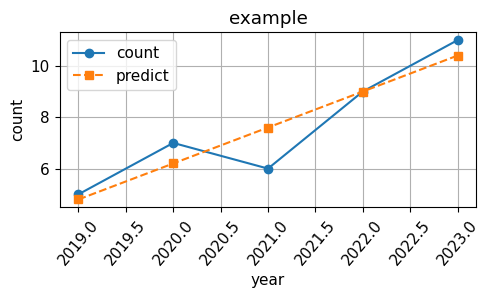

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
# api : 자주 사용되는 기능들을 한곳에 모아 편리하게 접근할 수 있도록 도와주는 역할

                            # 데이터 생성
data = {'year': [2019, 2020, 2021, 2022, 2023],
        'count': [5, 7, 6, 9, 11]}

df = pd.DataFrame(data)       # 데이터프레임 변환

x = df[['year']]              # x축, y축 설정
y = df[['count']]

x = sm.add_constant(x)        # 상수항(절편 추가)
model = sm.OLS(y, x).fit()    # 선형 회귀 모델 학습 :'Ordinary Least Squares-선형회귀분석 방법: 최소제곱법'

plt.figure(figsize = (5,3))   # 시각화
plt.plot(df['year'], df['count'], marker = 'o', label = 'count')
plt.plot(df['year'], model.predict(x), marker = 's', label = 'predict', linestyle = '--')
plt.title('example')
plt.xlabel('year')
plt.ylabel('count')
plt.xticks(rotation = 50)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()